In [1]:
import lsdb
from lsdb.streams import CatalogStream, InfiniteStream
import numpy as np
import nested_pandas as npd
import dask.dataframe as dd
from dask.distributed import Client
import time

In [2]:
cat7 = lsdb.open_catalog("catalogs/catalog7/generated_catalog")

In [52]:
def report_performance(catalog, n_workers, partitions_per_chunk, memory_limit="3GB"):
    print(f"number of workers: {n_workers}")
    print(f"partitions_per_chunk (streaming): {partitions_per_chunk}")
    results = {}

    with Client(threads_per_worker=1, n_workers=n_workers, dashboard_address=":8325", memory_limit=memory_limit) as client:
        time0 = time.time()
        catalog.compute()
        time1 = time.time()
    results["Compute/Client"] = time1 - time0

    with Client(threads_per_worker=1, n_workers=n_workers, dashboard_address=":8325", memory_limit=memory_limit) as client:
        stream = CatalogStream(catalog, partitions_per_chunk=partitions_per_chunk, shuffle=False)
        time0 = time.time()
        for chunk in stream:
            chunk
        time1 = time.time()
    results["Stream/Client"] = time1 - time0

    time0 = time.time()
    catalog.compute()
    time1 = time.time()
    results["Compute/NoClient"] = time1 - time0

    stream = CatalogStream(catalog, partitions_per_chunk=partitions_per_chunk, shuffle=False)
    time0 = time.time()
    for chunk in stream:
        chunk
    time1 = time.time()
    results["Stream/NoClient"] = time1 - time0

    return results

def collate_performance(catalog, n_workers_list, partitions_per_chunk_list, memory_limit="3GB"):
    all_results = {}

    # NoClient doesn't depend on n_workers, so only run it once
    for partitions_per_chunk in partitions_per_chunk_list:
        print(f"\n--- Running NoClient: partitions_per_chunk={partitions_per_chunk} ---")
        time0 = time.time()
        catalog.compute()
        time1 = time.time()
        compute_noclient = time1 - time0

        stream = CatalogStream(catalog, partitions_per_chunk=partitions_per_chunk, shuffle=False)
        time0 = time.time()
        for chunk in stream:
            chunk
        time1 = time.time()
        stream_noclient = time1 - time0

        all_results[(None, partitions_per_chunk)] = {
            "Compute/NoClient": compute_noclient,
            "Stream/NoClient": stream_noclient,
        }

    # Client results depend on both n_workers and partitions_per_chunk
    for n_workers in n_workers_list:
        for partitions_per_chunk in partitions_per_chunk_list:
            print(f"\n--- Running Client: n_workers={n_workers}, partitions_per_chunk={partitions_per_chunk} ---")

            with Client(threads_per_worker=1, n_workers=n_workers, dashboard_address=":8325", memory_limit=memory_limit) as client:
                time0 = time.time()
                catalog.compute()
                time1 = time.time()
                compute_client = time1 - time0

            with Client(threads_per_worker=1, n_workers=n_workers, dashboard_address=":8325", memory_limit=memory_limit) as client:
                stream = CatalogStream(catalog, partitions_per_chunk=partitions_per_chunk, shuffle=False)
                time0 = time.time()
                for chunk in stream:
                    chunk
                time1 = time.time()
                stream_client = time1 - time0

            all_results[(n_workers, partitions_per_chunk)] = {
                "Compute/Client": compute_client,
                "Stream/Client": stream_client,
            }

    return all_results

def plot_collated_results(all_results):
    import pandas as pd
    import matplotlib.pyplot as plt

    client_rows, noclient_rows = [], []
    for (n_workers, partitions_per_chunk), metrics in all_results.items():
        row = {"partitions_per_chunk": partitions_per_chunk, **metrics}
        if n_workers is None:
            noclient_rows.append(row)
        else:
            client_rows.append({"n_workers": n_workers, **row})

    client_df = pd.DataFrame(client_rows)
    noclient_df = pd.DataFrame(noclient_rows).sort_values("partitions_per_chunk")

    n_workers_vals = sorted(client_df["n_workers"].unique())
    prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
    fig.suptitle("`open_catalog` Performance Results", fontsize=14, fontweight="bold")

    # --- Client plot ---
    ax = axes[0]
    ax.set_title("Distributed Client")
    for i, n_workers in enumerate(n_workers_vals):
        color = prop_cycle[i % len(prop_cycle)]
        subset = client_df[client_df["n_workers"] == n_workers].sort_values("partitions_per_chunk")
        ax.plot(subset["partitions_per_chunk"], subset["Stream/Client"], marker="o",
                color=color, label=f"Stream ({n_workers} workers)")
        compute_mean = subset["Compute/Client"].mean()
        ax.axhline(compute_mean, color=color, linestyle="--",
                   label=f"Compute mean ({n_workers} workers)")

    ax.set_xlabel("partitions_per_chunk")
    ax.set_ylabel("Time (s)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # --- NoClient plot ---
    ax = axes[1]
    ax.set_title("Local Cluster (No Client)")
    color = prop_cycle[0]
    ax.plot(noclient_df["partitions_per_chunk"], noclient_df["Stream/NoClient"], marker="o",
            color=color, label="Stream")
    compute_mean = noclient_df["Compute/NoClient"].mean()
    ax.axhline(compute_mean, color=color, linestyle="--", label="Compute mean")

    ax.set_xlabel("partitions_per_chunk")
    ax.set_ylabel("Time (s)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return fig

In [53]:
results = collate_performance(cat7, n_workers_list=[1,3,9], partitions_per_chunk_list=[1, 3, 9, 27, 100])



--- Running NoClient: partitions_per_chunk=1 ---


Computing Catalog:   0%|          | 0/2377 [00:00<?, ?it/s]


--- Running NoClient: partitions_per_chunk=3 ---


Computing Catalog:   0%|          | 0/2377 [00:00<?, ?it/s]


--- Running NoClient: partitions_per_chunk=9 ---


...


--- Running NoClient: partitions_per_chunk=100 ---


Computing Catalog:   0%|          | 0/2377 [00:00<?, ?it/s]


--- Running Client: n_workers=1, partitions_per_chunk=1 ---

--- Running Client: n_workers=1, partitions_per_chunk=3 ---

--- Running Client: n_workers=1, partitions_per_chunk=9 ---

--- Running Client: n_workers=1, partitions_per_chunk=27 ---

--- Running Client: n_workers=1, partitions_per_chunk=100 ---

--- Running Client: n_workers=3, partitions_per_chunk=1 ---

--- Running Client: n_workers=3, partitions_per_chunk=3 ---

--- Running Client: n_workers=3, partitions_per_chunk=9 ---

--- Running Client: n_workers=3, partitions_per_chunk=27 ---

--- Running Client: n_workers=3, partitions_per_chunk=100 ---

--- Running Client: n_workers=9, partitions_per_chunk=1 ---


2026-03-30 13:22:03,587 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/Users/dbranton/.virtualenvs/lsdb/lib/python3.12/site-packages/distributed/comm/tcp.py", line 226, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/Users/dbranton/.virtualenvs/lsdb/lib/python3.12/site-packages/distributed/worker.py", line 1273, in heartbeat
    response = await retry_operation(
               ^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/dbranton/.virtualenvs/lsdb/lib/python3.12/site-packages/distributed/utils_comm.py", line 416, in retry_operation
    return await retry(
           ^^^^^^^^^^^^
  File "/Users/dbranton/.virtualenvs/lsdb/lib/python3.12/site-packages/distrib


--- Running Client: n_workers=9, partitions_per_chunk=3 ---

--- Running Client: n_workers=9, partitions_per_chunk=9 ---

--- Running Client: n_workers=9, partitions_per_chunk=27 ---

--- Running Client: n_workers=9, partitions_per_chunk=100 ---


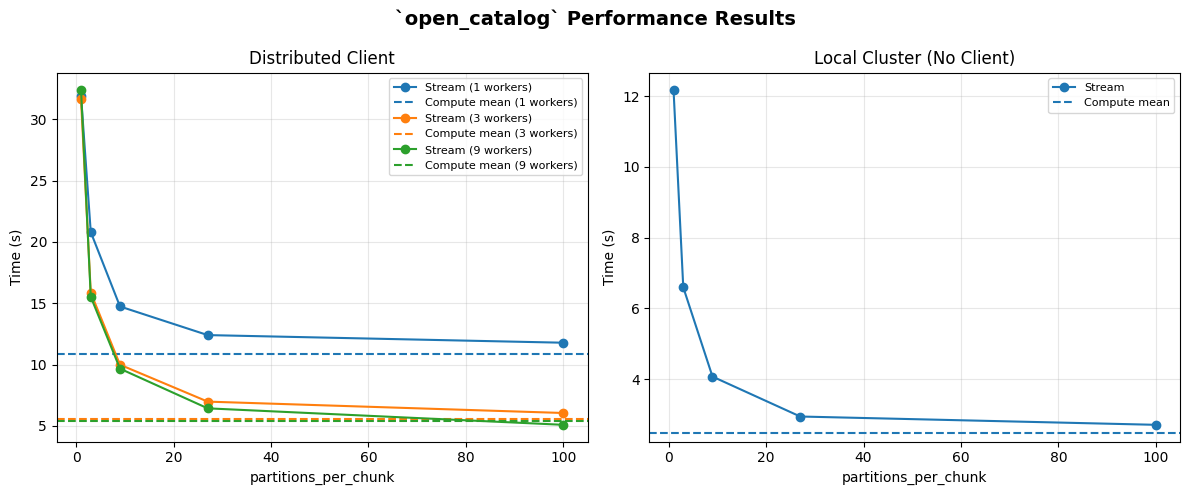

,ra,dec,id,a,b,nested
npartitions=792,,,,,,
"Order: 4, Pixel: 0",double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],"nested<t: [double], flux: [double], band: [str..."
"Order: 4, Pixel: 1",...,...,...,...,...,...
...,...,...,...,...,...,...
"Order: 4, Pixel: 1790",...,...,...,...,...,...
"Order: 4, Pixel: 1791",...,...,...,...,...,...


In [56]:

fig = plot_collated_results(results)
cat7

In [57]:
report_performance(cat7, n_workers=1, partitions_per_chunk=1)

number of workers: 1
partitions_per_chunk (streaming): 1


Computing Catalog:   0%|          | 0/2377 [00:00<?, ?it/s]

{'Compute/Client': 11.510451316833496,
 'Compute/NoClient': 2.237014055252075,
 'Stream/Client': 32.847448110580444,
 'Stream/NoClient': 12.290489196777344}

In [18]:
report_performance(cat7, n_workers=3, partitions_per_chunk=1)

number of workers: 3
partitions_per_chunk (streaming): 1


Computing Catalog:   0%|          | 0/2377 [00:00<?, ?it/s]

{'Compute/Client': 5.32175087928772,
 'Compute/NoClient': 2.2132978439331055,
 'Stream/Client': 27.416523694992065,
 'Stream/NoClient': 10.005696058273315}

In [19]:
report_performance(cat7, n_workers=1, partitions_per_chunk=3)

number of workers: 1
partitions_per_chunk (streaming): 3


Computing Catalog:   0%|          | 0/2377 [00:00<?, ?it/s]

{'Compute/Client': 9.235466003417969,
 'Compute/NoClient': 2.145796060562134,
 'Stream/Client': 18.1854829788208,
 'Stream/NoClient': 5.593891143798828}

In [20]:
report_performance(cat7, n_workers=3, partitions_per_chunk=3)

number of workers: 3
partitions_per_chunk (streaming): 3


Computing Catalog:   0%|          | 0/2377 [00:00<?, ?it/s]

{'Compute/Client': 5.138087749481201,
 'Compute/NoClient': 2.1671817302703857,
 'Stream/Client': 13.697587013244629,
 'Stream/NoClient': 5.7581658363342285}

In [30]:
report_performance(cat7, n_workers=9, partitions_per_chunk=9)

number of workers: 9
partitions_per_chunk (streaming): 9


Computing Catalog:   0%|          | 0/2377 [00:00<?, ?it/s]

{'Compute/Client': 4.361741065979004,
 'Compute/NoClient': 2.2298269271850586,
 'Stream/Client': 7.861262798309326,
 'Stream/NoClient': 3.2938899993896484}

In [22]:
report_performance(cat7, n_workers=3, partitions_per_chunk=9)

number of workers: 3
partitions_per_chunk (streaming): 9


Computing Catalog:   0%|          | 0/2377 [00:00<?, ?it/s]

{'Compute/Client': 5.2434399127960205,
 'Compute/NoClient': 2.172421932220459,
 'Stream/Client': 8.609047889709473,
 'Stream/NoClient': 3.286484956741333}

In [23]:
report_performance(cat7, n_workers=3, partitions_per_chunk=27)

number of workers: 3
partitions_per_chunk (streaming): 27


Computing Catalog:   0%|          | 0/2377 [00:00<?, ?it/s]

{'Compute/Client': 5.127762079238892,
 'Compute/NoClient': 2.1508092880249023,
 'Stream/Client': 6.455688953399658,
 'Stream/NoClient': 2.789520025253296}

In [24]:
report_performance(cat7, n_workers=9, partitions_per_chunk=27)

number of workers: 9
partitions_per_chunk (streaming): 27


Computing Catalog:   0%|          | 0/2377 [00:00<?, ?it/s]

{'Compute/Client': 4.167367935180664,
 'Compute/NoClient': 2.1498398780822754,
 'Stream/Client': 5.5543129444122314,
 'Stream/NoClient': 2.5499510765075684}

In [25]:
report_performance(cat7, n_workers=9, partitions_per_chunk=50)

number of workers: 9
partitions_per_chunk (streaming): 50


Computing Catalog:   0%|          | 0/2377 [00:00<?, ?it/s]

{'Compute/Client': 4.442920207977295,
 'Compute/NoClient': 1.9189376831054688,
 'Stream/Client': 5.188208818435669,
 'Stream/NoClient': 2.444145917892456}

In [29]:
report_performance(cat7, n_workers=9, partitions_per_chunk=100)

number of workers: 9
partitions_per_chunk (streaming): 100


Computing Catalog:   0%|          | 0/2377 [00:00<?, ?it/s]

{'Compute/Client': 4.544795989990234,
 'Compute/NoClient': 1.9156608581542969,
 'Stream/Client': 4.82169508934021,
 'Stream/NoClient': 2.3669471740722656}

In [27]:
report_performance(cat7, n_workers=9, partitions_per_chunk=1000)

number of workers: 9
partitions_per_chunk (streaming): 1000


Computing Catalog:   0%|          | 0/2377 [00:00<?, ?it/s]

{'Compute/Client': 4.554092168807983,
 'Compute/NoClient': 1.930284023284912,
 'Stream/Client': 4.65455174446106,
 'Stream/NoClient': 2.5931901931762695}

In [28]:
report_performance(cat7, n_workers=3, partitions_per_chunk=2377)

number of workers: 3
partitions_per_chunk (streaming): 2377


Computing Catalog:   0%|          | 0/2377 [00:00<?, ?it/s]

{'Compute/Client': 5.464634895324707,
 'Compute/NoClient': 1.8948850631713867,
 'Stream/Client': 5.668363094329834,
 'Stream/NoClient': 2.5468270778656006}